## IS 477 Final Project: Analysis of Electric Vehicle Data
**Team Members:** Kavya Moharana (kavyam3), Mahnur Khalid (mkhal2), Aisha Ziad (aziad2)

##### Research Questions: 
- What is the growth rate of electric vehicle registrations over time and are certain vehicle types (BEVs vs. PHEVs) growing faster in specific areas?
- How do electric vehicle registrations differ between states and how might this relate to factors like population density, income, or urbanization?
- How do trends in electric vehicle registration or sales in the USA compare to other countries globally and do they indicate a change in environmental consciousness?

### Data Preprocessing and Exploratory Data Analysis 

In [228]:
# Imports
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

##### Electric Vehicle Population Dataset from [Data.gov](https://catalog.data.gov/dataset/electric-vehicle-population-data)


In [58]:
# Reading in Data.gov dataset

url = "https://data.wa.gov/api/views/f6w7-q2d2/rows.json?accessType=DOWNLOAD"
response = requests.get(url)
json_data = response.json()
rows = json_data['data']
columns = [col['name'] for col in json_data['meta']['view']['columns']]

df_gov = pd.DataFrame(rows, columns=columns)
df_gov.head()

,sid,id,position,created_at,created_meta,updated_at,updated_meta,meta,VIN (1-10),County,...,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Counties,Congressional Districts,WAOFM - GIS - Legislative District Boundary
0,row-g3fz~tdtr-xivy,00000000-0000-0000-272F-E19A147DA10E,0,1732302668,None,1732302783,None,{ },1N4AZ0CP8D,King,...,75,0,32,125450447,POINT (-122.36498 47.72238),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033020100,3009,7,21
1,row-f9cj_f793_w2gv,00000000-0000-0000-3F8E-69378CFE90BC,0,1732302668,None,1732302783,None,{ },5YJSA1E45K,King,...,270,0,43,101662900,POINT (-122.30207 47.64085),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033006300,3009,7,4
2,row-8g8p.ic84.5vdw,00000000-0000-0000-3A0C-F00FFB7065F5,0,1732302668,None,1732302783,None,{ },WVGUNPE28M,Kitsap,...,0,0,26,272118717,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,53035092803,848,6,33
3,row-8y4z~5ism~my6k,00000000-0000-0000-0F61-B784FD56540A,0,1732302668,None,1732302783,None,{ },JTDKARFP6H,Thurston,...,25,0,22,349372929,POINT (-122.89166 47.03956),PUGET SOUND ENERGY INC,53067010400,2742,10,28
4,row-fbb4.tc3x-6jb4,00000000-0000-0000-F765-60514CBA66D5,0,1732302668,None,1732302783,None,{ },1FADP5CU9G,Thurston,...,19,0,22,171625653,POINT (-122.87741 47.05997),PUGET SOUND ENERGY INC,53067010300,2742,10,28


In [59]:
# Removing Unnecessary Columns
columns_todrop = ['sid', 'id', 'position', 'created_at', 'created_meta', 'updated_at',
                     'updated_meta', 'meta', 'Counties', 'Congressional Districts',
                     'WAOFM - GIS - Legislative District Boundary']
df_gov.drop(columns_todrop, axis=1, inplace=True)
df_gov.shape

(216772, 17)

In [60]:
# Checking for Duplicates
df_gov.duplicated().unique

<bound method Series.unique of 0         False
1         False
2         False
3         False
4         False
          ...  
216767    False
216768    False
216769    False
216770    False
216771    False
Length: 216772, dtype: bool>

In [61]:
# Checking for NA values
df_gov.isnull().sum()

VIN (1-10)                                             0
County                                                 5
City                                                   5
State                                                  0
Postal Code                                            5
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        19
Base MSRP                                             19
Legislative District                                 451
DOL Vehicle ID                                         0
Vehicle Location                                      11
Electric Utility                                       5
2020 Census Tract                                      5
dtype: int64

In [62]:
# Dropping rows with NA values by column name
df_gov = df_gov.dropna(subset=['County', 'City', 'Postal Code', 'Electric Range', 'Base MSRP', 'Legislative District', 
                                'Vehicle Location', 'Electric Utility', '2020 Census Tract'])
print(df_gov.isnull().values.any())
print(df_gov.shape)

False
(216296, 17)


#### Data Dictionary as per [The Washington State Open Data Portal](https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data)
The dataset contains **209709 observations**, where each row is a vehicle currently registered through Washington State Department of Licensing, and **17 columns** consisting of the following information:

**`VIN (1-10)`**
- [object] The 1st 10 characters of each vehicle's Vehicle Identification Number (VIN)

**`County`**
- [object] Geographic region of a state that a vehicle's owner is listed to reside within (vehicles registered in Washington state may be located in other states)

**`City`**
- [object] The city in which the registered owner resides

**`State`**
- [object] Geographic region of the country associated with the record (addresses may be located in other states)

**`Postal Code`**
- [float64] 5 digit zip code in which the registered owner resides

**`Model Year`**
- [int64] Model year of the vehicle, determined by decoding the Vehicle Identification Number (VIN)

**`Make`**
- [object] Manufacturer of the vehicle, determined by decoding the Vehicle Identification Number (VIN)

**`Electric Vehicle Type`**
- [object] Distinguishes the vehicle as all electric or a plug-in hybrid

**`Clean Alternative Fuel Vehicle (CAFV) Eligibility`**
- [object] Categorizes vehicle as Clean Alternative Fuel Vehicles (CAFVs) based on the fuel requirement and electric-only range requirement in House Bill 2042 (2019)

**`Electric Range`**
- [float64] Describes how far a vehicle can travel purely on its electric charge

**`Base MSRP`**
- [float64] The lowest Manufacturer's Suggested Retail Price (MSRP) for any trim level of the model in question

**`Legislative District`**
- [float64] Specific section of Washington State that the vehicle's owner resides in, as represented in the state legislature

**`DOL Vehicle ID`**
- [int64] Unique number assigned to each vehicle by Department of Licensing for identification purposes

**`Vehicle Location`**
- [object] The center of the ZIP Code for the registered vehicle

**`Electric Utility`**
- [object] The electric power retail service territories serving the address of the registered vehicle
    - ownership types for areas in Washington: federal, investor owned, municipal, political subdivision, cooperative

**`2020 Census Tract`**
- [float64] The census tract identifier is a combination of the state, county, and census tract codes as assigned by the U.S. Census Bureau in the 2020 census, also known as Geographic Identifier (GEOID)

#### Summary and Descriptive Statistics

In [214]:
# Quantitative Columns
print('Summary Statistics for EV Range and MSRP:')
numeric_columns = ['Electric Range', 'Base MSRP']
df_gov[numeric_columns] = df_gov[numeric_columns].apply(pd.to_numeric, errors='coerce')
df_numeric = df_gov[numeric_columns]
descriptive_stats = df_numeric.describe()
descriptive_stats

Summary Statistics for EV Range and MSRP:


,Electric Range,Base MSRP
count,216296.000000,216296.000000
mean,49.419629,869.119031
std,86.213449,7536.238606
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,42.000000,0.000000
max,337.000000,845000.000000


These statistics show a highly skewed distribution for both variables of Electric Range	and Base MSRP. The high maximum values, especially for Base MSRP, suggest that there are some very high-end electric vehicles in the dataset.

##### Electric Vehicle Population by US County Dataset from [Kaggle](https://www.kaggle.com/datasets/sahirmaharajj/electric-vehicle-population-size-2024/data?select=Electric_Vehicle_Population_Size_History_By_County_.csv)

In [123]:
df_county = pd.read_csv('Electric_Vehicle_Population_Size_History_By_County_.csv')
df_county.head()

,Date,County,State,Vehicle Primary Use,Battery Electric Vehicles (BEVs),Plug-In Hybrid Electric Vehicles (PHEVs),Electric Vehicle (EV) Total,Non-Electric Vehicle Total,Total Vehicles,Percent Electric Vehicles
0,September 30 2022,Riverside,CA,Passenger,7,0,7,460,467,1.50
1,December 31 2022,Prince William,VA,Passenger,1,2,3,188,191,1.57
2,January 31 2020,Dakota,MN,Passenger,0,1,1,32,33,3.03
3,June 30 2022,Ferry,WA,Truck,0,0,0,"3,575","3,575",0.00
4,July 31 2021,Douglas,CO,Passenger,0,1,1,83,84,1.19


In [124]:
# Checking for NA values and Duplicates
print(df_county.isnull().sum())
print(df_county.duplicated().unique)

Date                                         0
County                                      86
State                                       86
Vehicle Primary Use                          0
Battery Electric Vehicles (BEVs)             0
Plug-In Hybrid Electric Vehicles (PHEVs)     0
Electric Vehicle (EV) Total                  0
Non-Electric Vehicle Total                   0
Total Vehicles                               0
Percent Electric Vehicles                    0
dtype: int64
<bound method Series.unique of 0        False
1        False
2        False
3        False
4        False
         ...  
20814    False
20815    False
20816    False
20817    False
20818    False
Length: 20819, dtype: bool>


In [125]:
# Dropping rows with NA values by County and State columns
df_county = df_county.dropna(subset=['County', 'State'])
print(df_county.isnull().values.any())
print(df_county.shape)

False
(20733, 10)


#### Data Dictionary as per [Kaggle's Data Card](https://data.wa.gov/Transportation/Electric-Vehicle-Population-Data/f6w7-q2d2/about_data)
The dataset contains **20733 observations**, where each row represents the vehicles registered by the Washington State Department of Licensing (DOL) each month between 2017 to 2024, and **10 columns** consisting of the following information:

**`Date`**
- [object] Counts of registered vehicles were taken on this day (the end of the month)

**`County`**
- [object] The geographic region of a state that a vehicle's owner is listed to reside within

**`State`**
- [object] The geographic region of the U.S. associated with the record

**`Vehicle Primary Use`**
- [object] Describes the primary intended use of the vehicle, one of either Passenger or Truck

**`Battery Electric Vehicles (BEVs)`**
- [object] The count of vehicles that are known to be propelled solely by an energy derived from an onboard electric battery

**`Plug-In Hybrid Electric Vehicles (PHEVs)`**
- [object] The count of vehicles that are known to be propelled from energy partially sourced from an onboard electric battery

**`Electric Vehicle (EV) Total`**
- [object] The sum of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs)

**`Non-Electric Vehicle Total`**
- [object] The count of vehicles that are not electric vehicles

**`Total Vehicles`**
- [object] All powered vehicles registered in the county, including electric vehicles

**`Percent Electric Vehicles`**
- [float64] Comparison of electric vehicles versus their non-electric counterparts

##### Global Electric Vehicle Sales Dataset from [Kaggle](https://www.kaggle.com/datasets/patricklford/global-ev-sales-2010-2024/data)

In [176]:
df_sales = pd.read_csv('IEA Global EV Data 2024.csv')
df_sales.sample(5)

,region,category,parameter,mode,powertrain,year,unit,value
7923,Norway,Historical,EV stock share,Trucks,EV,2023,percent,1.40
6764,Japan,Historical,EV stock share,Vans,EV,2023,percent,0.13
12020,World,Projection-STEPS,EV stock,Vans,BEV,2021,Vehicles,610000.00
8267,Portugal,Historical,EV stock,Cars,BEV,2021,Vehicles,37000.00
9671,Spain,Historical,EV sales share,Buses,EV,2023,percent,13.00


In [177]:
na_values = df_sales.isna().sum()
na_values

region        0
category      0
parameter     0
mode          0
powertrain    0
year          0
unit          0
value         0
dtype: int64

#### Data Dictionary as per [Kaggle's Data Card](https://www.kaggle.com/datasets/patricklford/global-ev-sales-2010-2024/data)
The dataset contains **12654 observations**, where each row represents electric vehicle sales, stock, or stock share data for various regions of the world from 2010 to 2023, and **8 columns** consisting of the following information:

**`region`**
- [object] geographic region of the world either by country name, continent, etc.

**`category`**
- [object] type of data reading, either historical or IEA future projection

**`parameter`**
- [object] type of EV business/finance data insight—either sales, stocks, or shares

**`mode`**
- [object] type of vehicle

**`powertrain`**
- [object] main battery component type, such as BEV, PHEV, FCEV, etc.

**`year`**
- [int64] year of EV data point between 2010 to 2023

**`unit`**
- [object] unit of measurement for data reading

**`value`**
- [float64] numeric value of data point that corresponds to the unit

### 1. What is the growth rate of electric vehicle registrations over time and are certain vehicle types (BEVs vs. PHEVs) growing faster in specific areas?
**by Kavya Moharana**

##### **Analyzing the Growth Rate of EV Registrations Over Time**

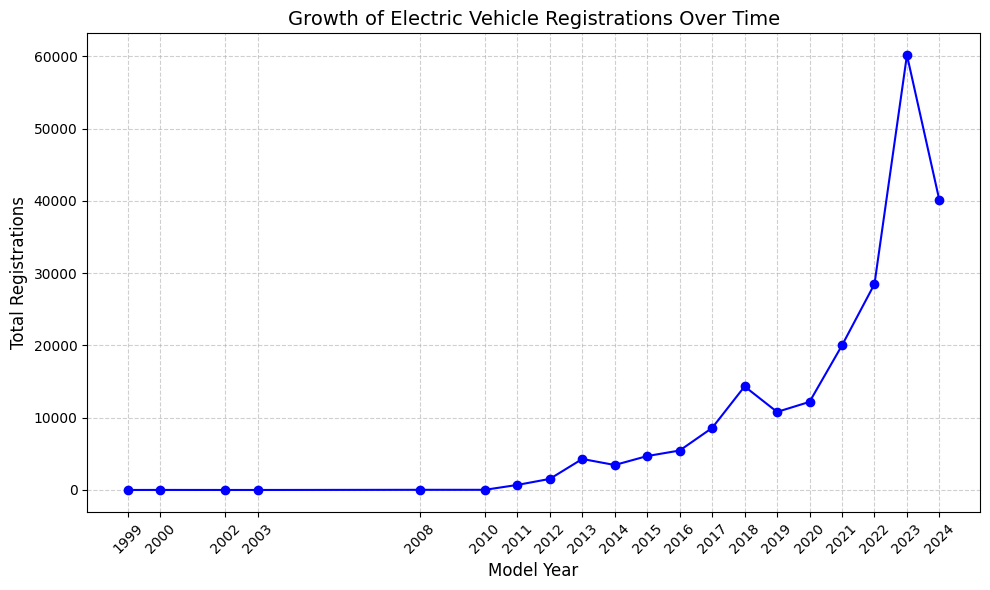

In [215]:
df_gov['Model Year'] = pd.to_numeric(df_gov['Model Year'], errors='coerce')

yearly_totals = df_gov.groupby('Model Year').size().reset_index(name='Total Registrations')
yearly_totals = yearly_totals[yearly_totals['Model Year'] != 2025]

plt.figure(figsize=(10, 6))
plt.plot(yearly_totals['Model Year'], yearly_totals['Total Registrations'], marker='o', color='b', linestyle='-')
plt.title('Growth of Electric Vehicle Registrations Over Time', fontsize=14)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Total Registrations', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(yearly_totals['Model Year'], rotation=45)
plt.tight_layout()
plt.show()

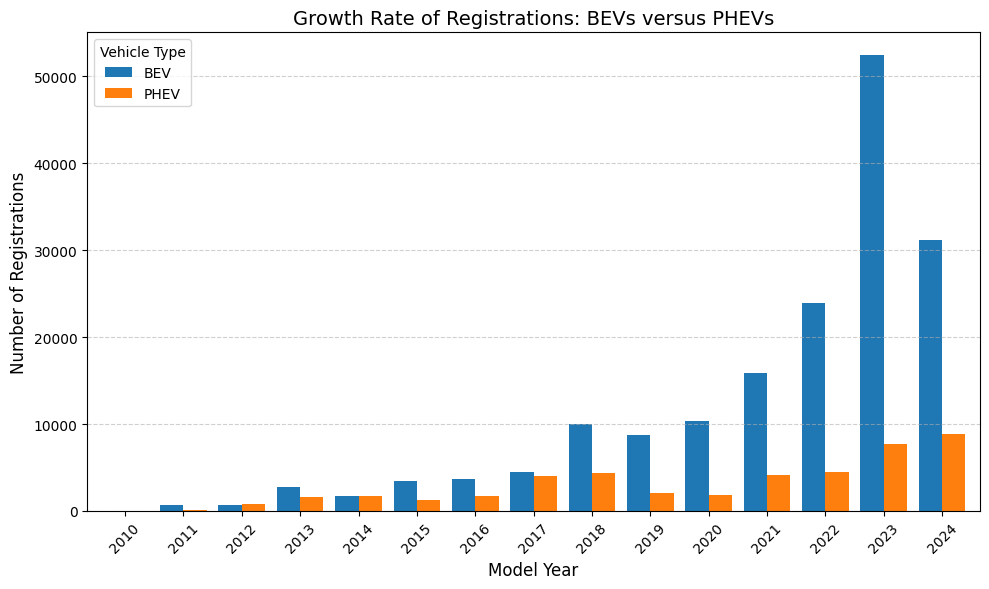

In [216]:
vehicle_type_trends = df_gov.groupby(['Model Year', 'Electric Vehicle Type']).size().reset_index(name='Count')
vehicle_type_trends = vehicle_type_trends[vehicle_type_trends['Model Year'] != 2025]


# Pivot to create a table with BEV and PHEV counts
pivot_table = vehicle_type_trends.pivot(index='Model Year', columns='Electric Vehicle Type', values='Count').fillna(0)
pivot_table = pivot_table.rename(columns={'Battery Electric Vehicle (BEV)': 'BEV', 'Plug-in Hybrid Electric Vehicle (PHEV)': 'PHEV'})

# Create grouped bar chart
pivot_table = pivot_table[pivot_table.index >= 2010]

pivot_table.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Growth Rate of Registrations: BEVs versus PHEVs', fontsize=14)
plt.xlabel('Model Year', fontsize=12)
plt.ylabel('Number of Registrations', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

##### **Regional Trends in BEVs and Electric Vehicle Adoption**

EV Registrations by County and City in Washington:

In [105]:
county_counts = df_gov['County'].value_counts().reset_index()
county_counts.columns = ['County', 'Registration Count']

county_counts['Percentage'] = (county_counts['Registration Count'] / county_counts['Registration Count'].sum()) * 100
print("EV Registrations by County in Washington State:")
county_counts.head(10)

EV Registrations by County in Washington State:


,County,Registration Count,Percentage
0,King,110154,50.927433
1,Snohomish,26198,12.112106
2,Pierce,17397,8.043145
3,Clark,12934,5.979768
4,Thurston,7938,3.669971
5,Kitsap,7214,3.335244
6,Spokane,5996,2.772127
7,Whatcom,5243,2.423993
8,Benton,2725,1.259848
9,Skagit,2447,1.131320


In [106]:
city_counts = df_gov['City'].value_counts().reset_index()
city_counts.columns = ['City', 'Registration Count']

print("EV Registrations by City:")
city_counts.head(10)

EV Registrations by City:


,City,Registration Count
0,Seattle,34751
1,Bellevue,10725
2,Vancouver,7726
3,Redmond,7655
4,Bothell,7060
5,Kirkland,6284
6,Renton,6277
7,Sammamish,6173
8,Olympia,5188
9,Tacoma,4656


In [89]:
aggregated = (
    df_gov.groupby(['County', 'Electric Vehicle Type', 'Model Year'])
    .size()
    .reset_index(name='Vehicle Count')
)

# Calculate Annual Growth Rates
aggregated = aggregated.sort_values(by=['County', 'Electric Vehicle Type', 'Model Year'])

# Calculate year-over-year growth rates
aggregated['Growth Rate (%)'] = (
    aggregated.groupby(['County', 'Electric Vehicle Type'])['Vehicle Count']
    .pct_change() * 100
)

bev_growth = aggregated[aggregated['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']
phev_growth = aggregated[aggregated['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']

bev_vs_phev = (
    bev_growth.set_index(['County', 'Model Year'])['Growth Rate (%)']
    .subtract(phev_growth.set_index(['County', 'Model Year'])['Growth Rate (%)'])
    .reset_index(name='BEV Growth Advantage (%)')
)

# Highlighting counties with faster growth for BEVs or PHEVs
bev_faster_growth = bev_vs_phev[bev_vs_phev['BEV Growth Advantage (%)'] > 0]

highest_bev = bev_vs_phev.groupby('County')['BEV Growth Advantage (%)'].max().reset_index().dropna()
highest_bev = highest_bev.sort_values(by='BEV Growth Advantage (%)', ascending=False)

In [93]:
# Results
print("Top 15 Counties in Washington with BEVs Growing Faster:")
highest_bev.head(15)

Top 15 Counties in Washington with BEVs Growing Faster:


,County,BEV Growth Advantage (%)
26,Pierce,5700.000000
33,Thurston,2600.000000
31,Spokane,1500.000000
10,Franklin,1316.666667
34,Wahkiakum,633.333333
1,Asotin,516.666667
24,Pacific,500.000000
15,Jefferson,411.764706
12,Grant,400.000000
23,Okanogan,371.428571


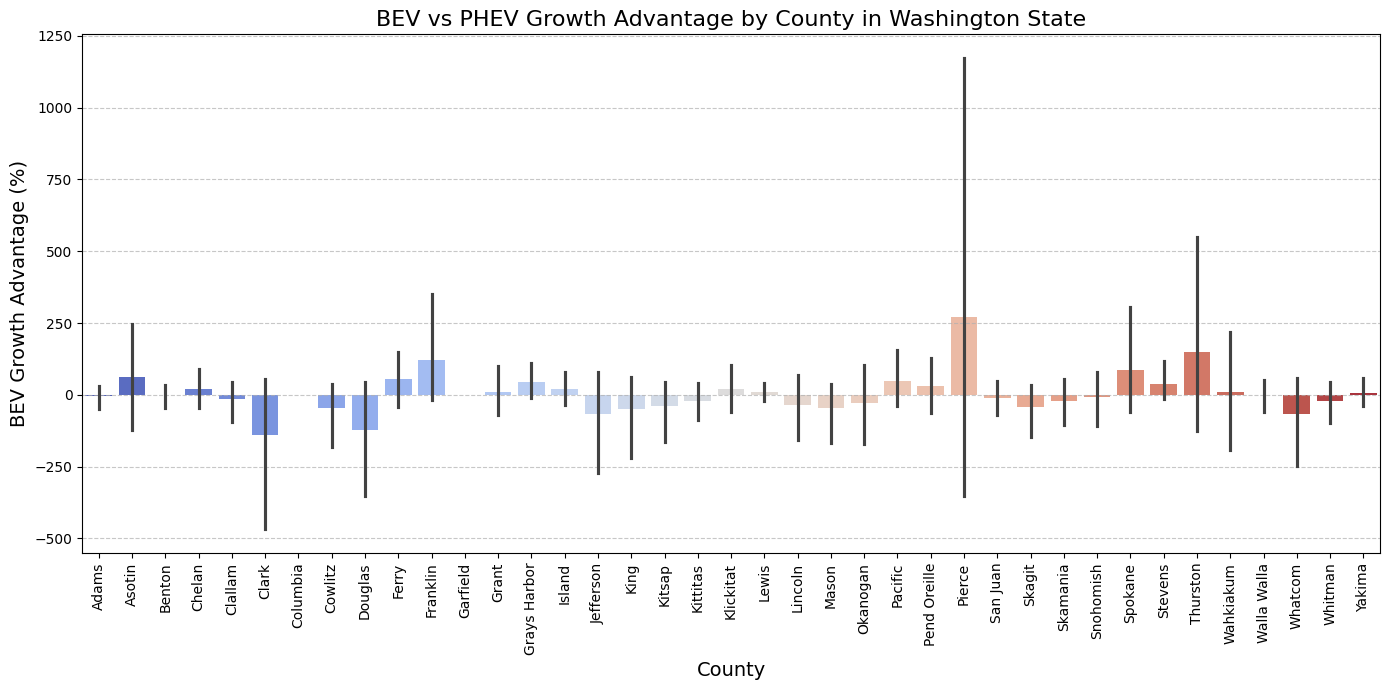

In [92]:
plt.figure(figsize=(14, 7))

sns.barplot(x='County', y='BEV Growth Advantage (%)', hue='County', data=bev_vs_phev, palette='coolwarm')

plt.title('BEV vs PHEV Growth Advantage by County in Washington State', fontsize=16)
plt.xlabel('County', fontsize=14)
plt.ylabel('BEV Growth Advantage (%)', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

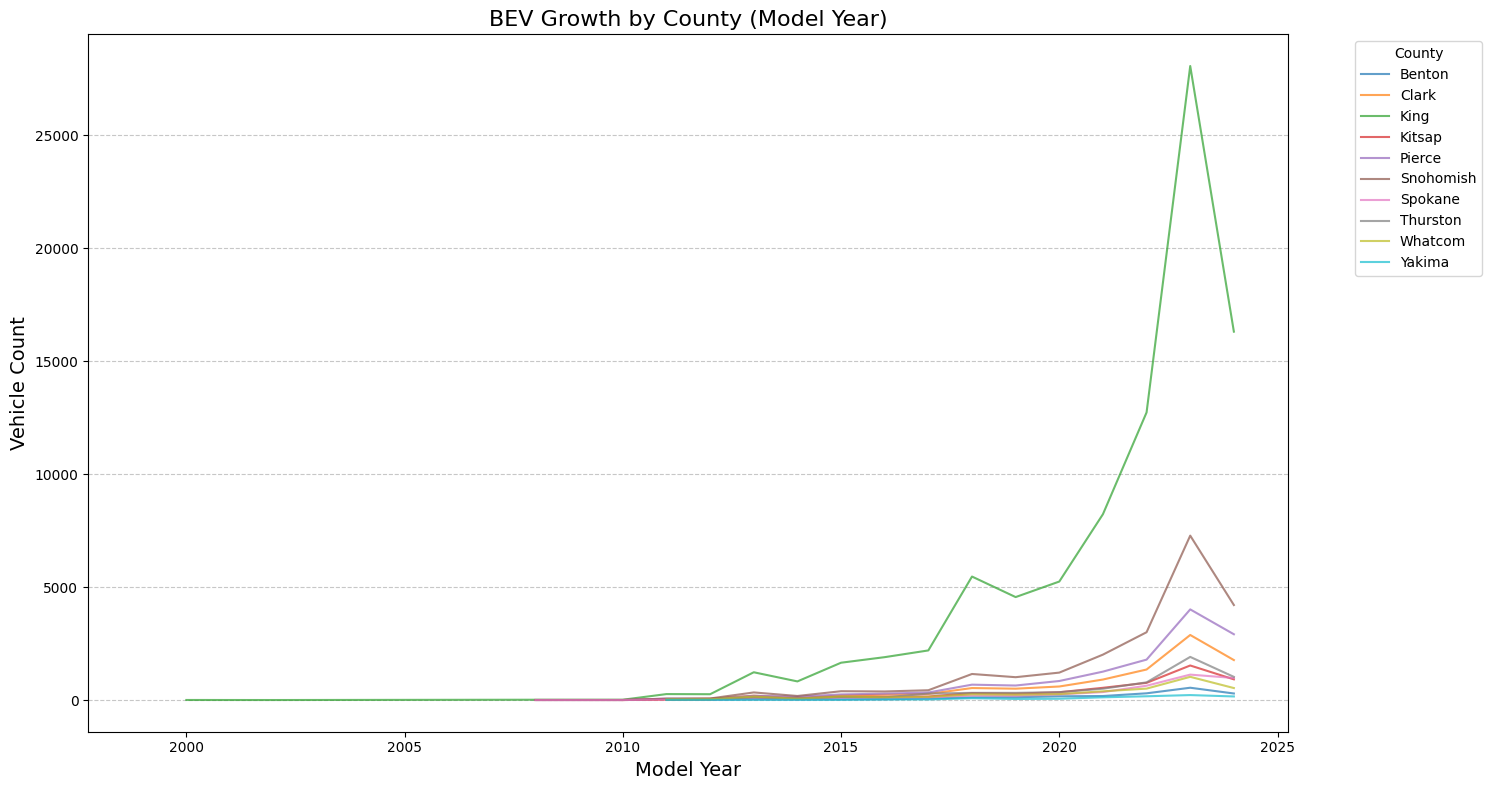

In [224]:
bev_data_filtered = aggregated[
    (aggregated['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)') &
    (aggregated['County'].isin([
        "King", "Pierce", "Snohomish", "Spokane", "Clark",
        "Thurston", "Kitsap", "Yakima", "Whatcom", "Benton"
    ]))
]
bev_data_filtered = bev_data_filtered[bev_data_filtered['Model Year'] != 2025]

# Pivoting the data for each county to be a separate line
bev_pivot = bev_data_filtered.pivot_table(
    index='Model Year',
    columns='County',
    values='Vehicle Count',
    aggfunc='sum'
)

plt.figure(figsize=(15, 8))

for county in bev_pivot.columns:
    plt.plot(bev_pivot.index, bev_pivot[county], label=county, alpha=0.7)

plt.title("BEV Growth by County (Model Year)", fontsize=16)
plt.xlabel("Model Year", fontsize=14)
plt.ylabel("Vehicle Count", fontsize=14)
plt.legend(title="County", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. How do electric vehicle registrations differ between states and how might this relate to factors like population density, income, or urbanization?
**by Mahnur Khalid**

In [126]:
df_county['Battery Electric Vehicles (BEVs)'] = pd.to_numeric(df_county['Battery Electric Vehicles (BEVs)'].str.replace(',', ''))
df_county['Plug-In Hybrid Electric Vehicles (PHEVs)'] = pd.to_numeric(df_county['Plug-In Hybrid Electric Vehicles (PHEVs)'].str.replace(',', ''))
df_county['Electric Vehicle (EV) Total'] = pd.to_numeric(df_county['Electric Vehicle (EV) Total'].str.replace(',', ''))
df_county['Non-Electric Vehicle Total'] = pd.to_numeric(df_county['Non-Electric Vehicle Total'].str.replace(',', ''))
df_county['Total Vehicles'] = pd.to_numeric(df_county['Total Vehicles'].str.replace(',', ''))

In [127]:
df_county.dtypes

Date                                         object
County                                       object
State                                        object
Vehicle Primary Use                          object
Battery Electric Vehicles (BEVs)              int64
Plug-In Hybrid Electric Vehicles (PHEVs)      int64
Electric Vehicle (EV) Total                   int64
Non-Electric Vehicle Total                    int64
Total Vehicles                                int64
Percent Electric Vehicles                   float64
dtype: object

In [137]:
states = df_county.groupby('State')[['Percent Electric Vehicles']].mean().sort_values('Percent Electric Vehicles', ascending=False)
print('Percent of Registered Electric Vehicles by State (Top 20)')
top_20 = states.head(20)
top_20

Percent of Registered Electric Vehicles by State (Top 20)


,Percent Electric Vehicles
State,
AR,58.265814
IA,56.629524
PR,55.000217
NH,22.017131
WI,19.426000
IN,18.760950
MO,15.145224
WY,14.269286
OH,13.291926


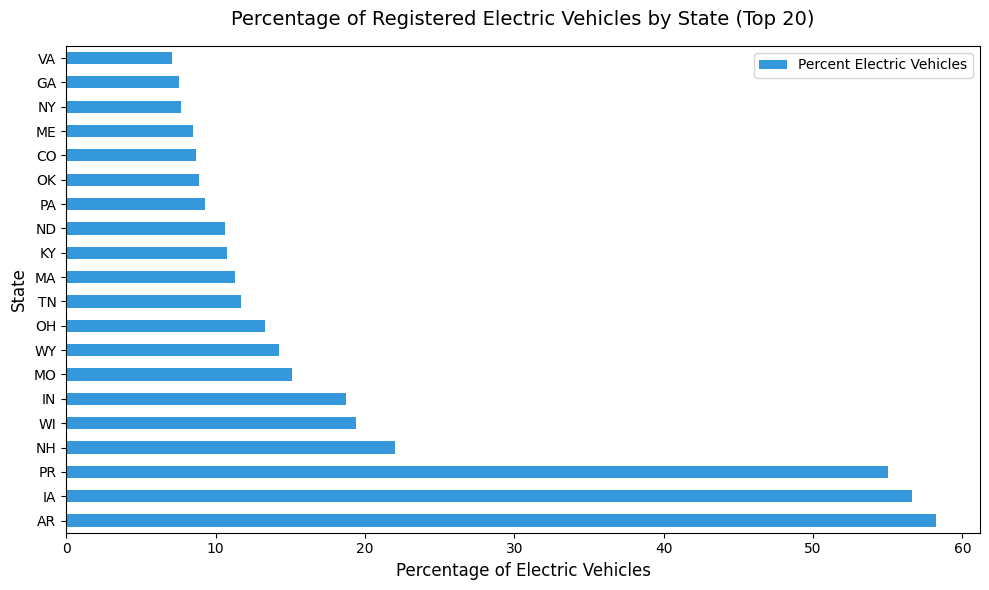

In [154]:
fig, ax = plt.subplots(figsize=(10, 6))
top_20.plot(kind='barh', ax=ax, color='#3498db')

ax.set_title('Percentage of Registered Electric Vehicles by State (Top 20)', fontsize=14, pad=15)
ax.set_xlabel('Percentage of Electric Vehicles', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.show()

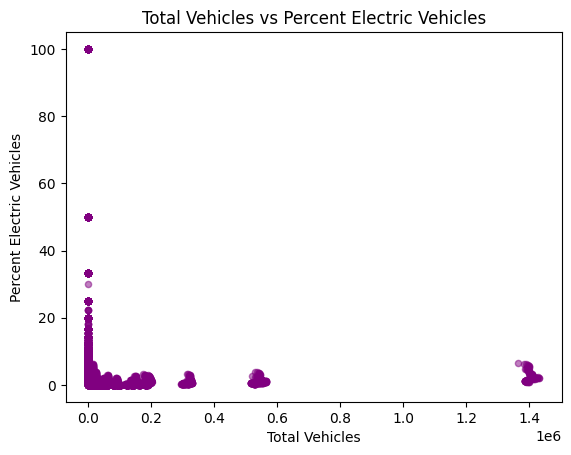

In [155]:
df_county.plot.scatter(x='Total Vehicles', y='Percent Electric Vehicles', alpha=0.5, color='purple')
plt.title('Total Vehicles vs Percent Electric Vehicles')
plt.xlabel('Total Vehicles')
plt.ylabel('Percent Electric Vehicles')
plt.show()

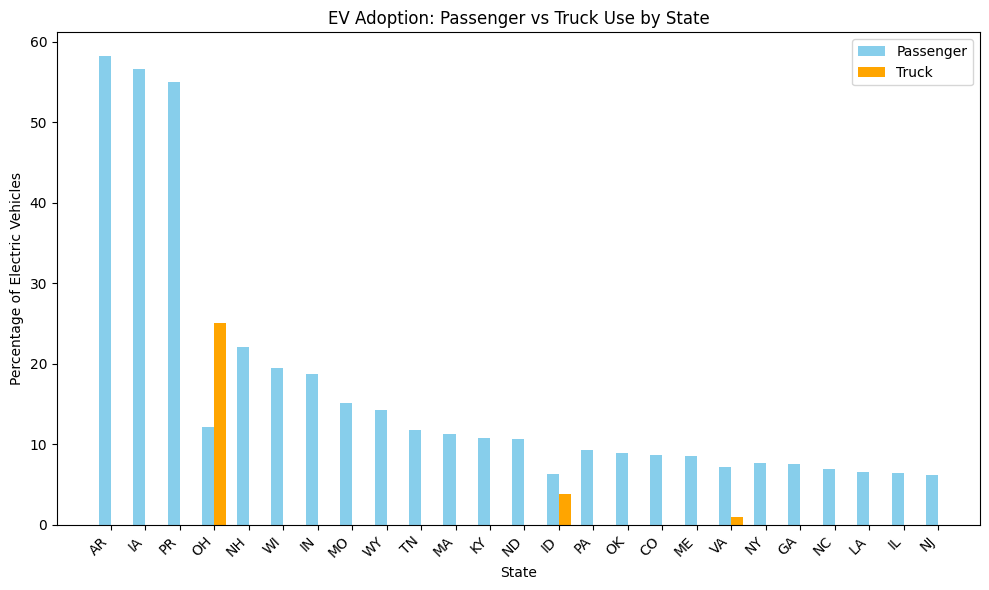

In [227]:
grouped_data = df_county.groupby(['State', 'Vehicle Primary Use'])['Percent Electric Vehicles'].mean().unstack()

top_states = grouped_data.sum(axis=1).nlargest(25).index
grouped_data = grouped_data.loc[top_states]

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(grouped_data.index))

ax.bar(x - width/2, grouped_data['Passenger'], width, label='Passenger', color='skyblue')
ax.bar(x + width/2, grouped_data['Truck'], width, label='Truck', color='orange')

ax.set_xlabel('State')
ax.set_ylabel('Percentage of Electric Vehicles')
ax.set_title('EV Adoption: Passenger vs Truck Use by State')
ax.set_xticks(x)
ax.set_xticklabels(grouped_data.index, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()


### 3. How do trends in electric vehicle registration or sales in the USA compare to other countries globally and do they indicate a change in environmental consciousness?
**by Aisha Ziad**

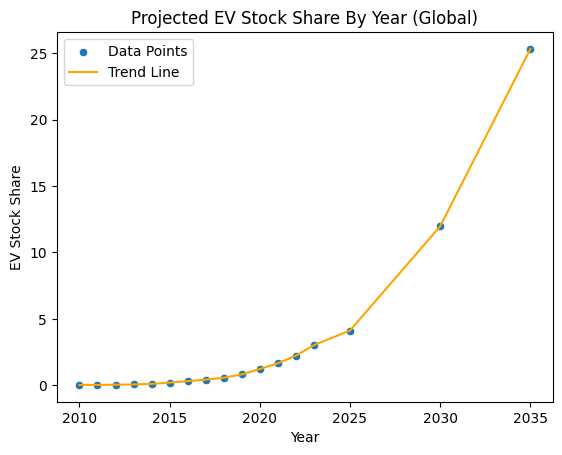

In [184]:
group_year = df_sales[df_sales['parameter'].isin(['EV stock share'])].groupby(['year', 'parameter'])['value'].mean().reset_index()
sns.scatterplot(x=group_year['year'], y=group_year['value'], label="Data Points")
plt.plot(group_year['year'], group_year['value'], label="Trend Line", color='orange')

plt.title("Projected EV Stock Share By Year (Global)")
plt.xlabel("Year")
plt.ylabel("EV Stock Share")
plt.legend()
plt.grid(False)
plt.show()

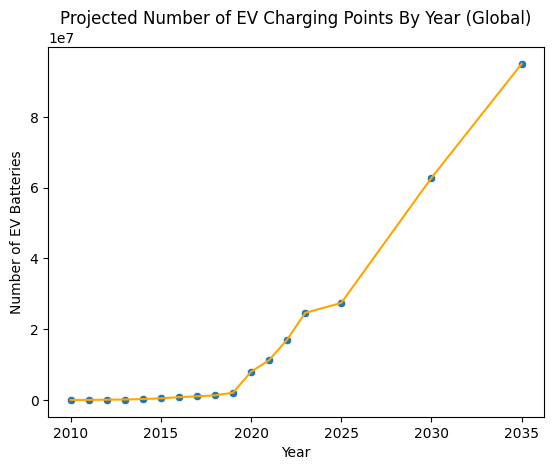

In [195]:
num_charging_points = df_sales[df_sales['parameter'] == 'EV charging points'].groupby(['year', 'mode'])['value'].sum().reset_index()
sns.scatterplot(x = num_charging_points['year'], y=num_charging_points['value'])
plt.plot(num_charging_points['year'], num_charging_points['value'], label="Trend Line", color='orange')

plt.title("Projected Number of EV Charging Points By Year (Global)")
plt.xlabel("Year")
plt.ylabel("Number of EV Batteries")
plt.grid(False)
plt.show()

In [181]:
df_sales_clean = df_sales.drop(df_sales[df_sales['region'].isin(['EU27', 'Rest of the world', 'World'])].index)

In [213]:
print("EV stock shares by Global Region:")
group_region_year = df_sales_clean[df_sales_clean['parameter'].isin(['EV stock share'])].groupby(['year', 'parameter', 'region'])['value'].mean().reset_index()
group_region_year

EV stock shares by Global Region:


,year,parameter,region,value
0,2010,EV stock share,Austria,0.007900
1,2010,EV stock share,Belgium,0.008150
2,2010,EV stock share,China,0.015927
3,2010,EV stock share,Denmark,0.008367
4,2010,EV stock share,Europe,0.120725
...,...,...,...,...
431,2030,EV stock share,USA,14.125000
432,2035,EV stock share,China,41.500000
433,2035,EV stock share,Europe,27.875000
434,2035,EV stock share,India,14.750000


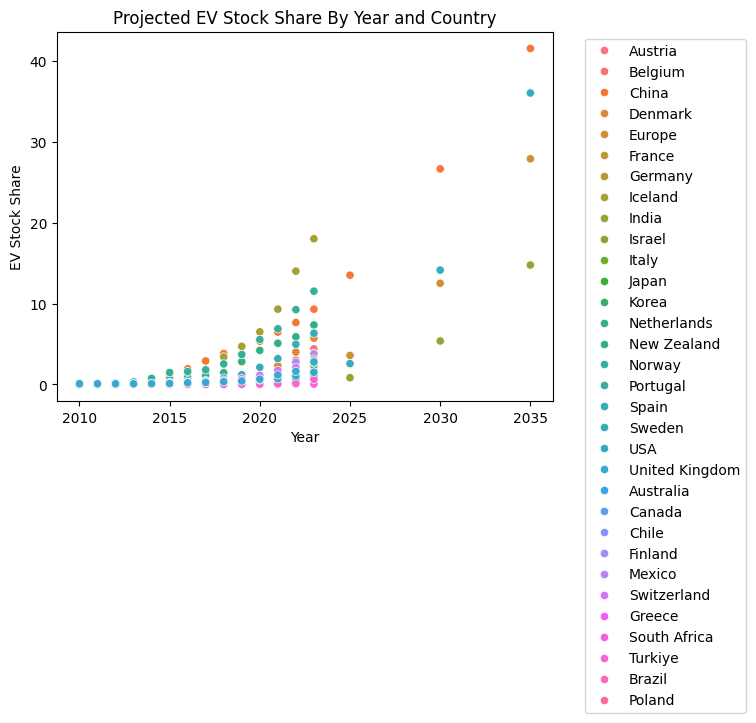

In [226]:
sns.scatterplot(x=group_region_year['year'], y=group_region_year['value'], hue=group_region_year['region'])

plt.title("Projected EV Stock Share By Year and Country")
plt.xlabel("Year")
plt.ylabel("EV Stock Share")
plt.grid(False)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

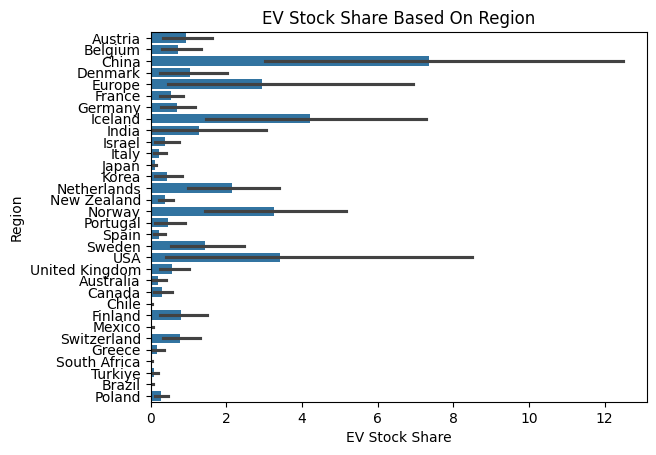

In [210]:
sns.barplot(x = group_region_year['value'], y=group_region_year['region'])
plt.title("EV Stock Share Based On Region")
plt.ylabel("Region")
plt.xlabel("EV Stock Share")
plt.grid(False)
plt.show()

In [199]:
num_charging_points2 = df_sales_clean[df_sales_clean['parameter'] == 'EV charging points'].groupby(['year', 'mode', 'region'])['value'].sum().reset_index()
num_charging_points2

,year,mode,region,value
0,2010,EV,Europe,3200.0
1,2010,EV,Japan,310.0
2,2010,EV,Netherlands,400.0
3,2010,EV,Norway,2800.0
4,2010,EV,USA,480.0
...,...,...,...,...
370,2030,EV,USA,1820000.0
371,2035,EV,China,31400000.0
372,2035,EV,Europe,5500000.0
373,2035,EV,India,2638000.0


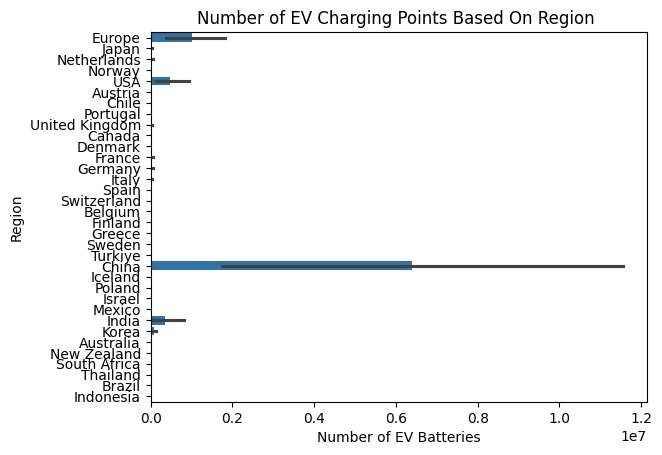

In [211]:
sns.barplot(x = num_charging_points2['value'], y=num_charging_points2['region'])
plt.title("Number of EV Charging Points Based On Region ")
plt.xlabel("Number of EV Batteries")
plt.ylabel("Region")
plt.grid(False)
plt.show()